In [105]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import time

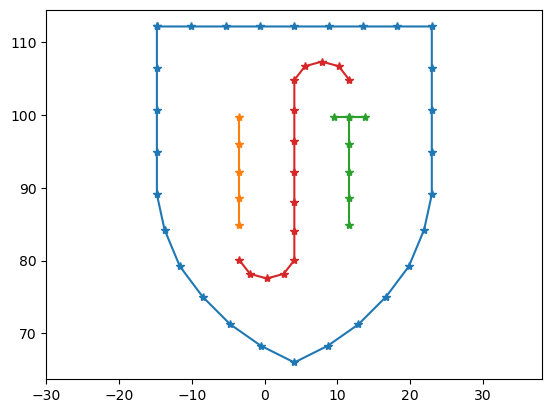

In [106]:
from ISTlogo_traj import ISTlogo_traj
[traj ,traj_] = ISTlogo_traj();

In [107]:
def sinX(alpha):
    if (abs(np.sin(alpha)) < 1e-14) and (abs(alpha) < np.pi):
        y = 1
    else:
        y = np.sin(alpha) / alpha

    return y

######################################################################################################


def A_btSpring(la, lb, lc, w):
    rotz = lambda t: np.array([[np.cos(t), -np.sin(t), 0],
                               [np.sin(t), np.cos(t), 0],
                               [0, 0, 1]])
    roty = lambda t: np.array([[np.cos(t), 0, np.sin(t)],
                               [0, 1, 0],
                               [-np.sin(t), 0, np.cos(t)]])

    l_avg = (la + lb + lc) / 3
    th = 2 * np.sqrt(la**2 + lb**2 + lc**2 - (la*lb + la*lc + lb*lc)) / (3 * w)
    # r = l_avg/th
    phi = np.arctan2(np.sqrt(3)*(lc-lb), lb+lc-2*la)

    x =  l_avg * sinX(th/2) * np.cos((np.pi-th)/2) * np.sin(phi - np.pi/2)
    y = -l_avg * sinX(th/2) * np.cos((np.pi-th)/2) * np.cos(phi - np.pi/2)
    z =  l_avg * sinX(th/2) * np.sin((np.pi-th)/2)

    o_bt = np.array([x, y, z])
    R_bt = rotz(phi) @ roty(-th) @ rotz(-phi)

    A_bt = np.row_stack((np.column_stack((R_bt, o_bt)), [0, 0, 0, 1]))

    return A_bt

######################################################################################################

def T_mat(val):
    return np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, val],
        [0, 0, 0, 1]
    ])

######################################################################################################

def DK(traj):
    
    jt2l = lambda p: ((p-316.1)/-2.468)
    
    traj = jt2l(traj)
    
    decimals=10
    
    # Robot arm parameters
    h1, h2, h3, R, res = 3, 3, 7.1 + 7.6, 18.75, 10
    
    base = []
    if len(base) == 0:
        base = np.eye(4)

    end_effector_positions = []  # Store each end effector position

    for p in traj:
        la, lb, lc = (p[0] - (h1 + h2 + h3)) / 2, (p[1] - (h1 + h2 + h3)) / 2, (p[2] - (h1 + h2 + h3)) / 2

        T_b0 = base @ T_mat(h1)
        A_01 = A_btSpring(la, lb, lc, R)
        T_12 = T_mat(h2)
        A_23 = A_01
        T_3e = T_mat(h3)

        T_be = T_b0 @ A_01 @ T_12 @ A_23 @ T_3e
        
        x, y, z = T_be[0, 3], T_be[1, 3], T_be[2, 3]
        end_effector_positions.append([x, y, z])

    return np.array(end_effector_positions)

######################################################################################################

def plot_end_effector_positions(end_effector_positions,mode='markers+lines'):
    # mode = 'markers+lines' or mode = 'markers'
    # Extract x, y, z coordinates
    x = end_effector_positions[:, 0]
    y = end_effector_positions[:, 1]
    z = end_effector_positions[:, 2]

    # Create the 3D scatter plot
    fig = go.Figure(data=[go.Scatter3d(x=x, y=y, z=z, mode=mode,
                                       marker=dict(size=3, color='blue'),
                                       line=dict(color='blue', width=2))])

    # Update plot layout
    fig.update_layout(
        title='End Effector Positions',
        scene=dict(
            xaxis_title='X Axis',
            yaxis_title='Y Axis',
            zaxis_title='Z Axis',
            xaxis=dict(range=[min(x), max(x)]),
            yaxis=dict(range=[min(y), max(y)]),
            zaxis=dict(range=[min(z), max(z)])
        ),
        margin=dict(r=10, l=10, b=10, t=30)
    )

    # Show plot
    fig.show()
    
######################################################################################################


In [108]:
def generate_joints_grid(start, stop, num_points=10):
    """
    Generates a 3D grid of points for j1, j2, j3.

    :param start: The starting value for each joint.
    :param stop: The stopping value for each joint.
    :param num_points: Number of points along each dimension.
    :return: A 2D numpy array where each row is a combination of (j1, j2, j3).
    """
    j1, j2, j3 = np.mgrid[start:stop:num_points*1j, start:stop:num_points*1j, start:stop:num_points*1j]
    grid = np.vstack([j1.ravel(), j2.ravel(), j3.ravel()]).T
    return grid

In [109]:

# Example usage
end_effector_positions = DK(traj)  # Assuming this is calculated from your DK function
plot_end_effector_positions(end_effector_positions)


In [118]:
# Example usage just to show it plotted
start_val = 15
stop_val = 165

joints_grid = generate_joints_grid(start_val, stop_val, num_points=10) # 10^3=1000 Points

end_effector_positions = DK(joints_grid)  # Assuming this is calculated from your DK function
plot_end_effector_positions(end_effector_positions,mode = 'markers')

In [119]:
# Generate the dataset with ~10 000

joints_grid            = generate_joints_grid(start_val, stop_val, num_points=22) # 22^3 ~ 10 000 Points
end_effector_positions = DK(joints_grid)

### Train NN Robot Model

In [124]:
# Concatenate the joint values with the corresponding end effector positions
dataset = np.hstack((joints_grid, end_effector_positions))
df = pd.DataFrame(dataset, columns=['j1', 'j2', 'j3', 'x', 'y', 'z']) # Convert to DataFrame

# Save the dataset
#df.to_csv('robot_arm_dataset.csv', index=False)

##############################################################################################

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from tensorflow.keras.callbacks import Callback
import sys

# Callback for displaying training progress every X epochs (plot it every epoch is annoying)
class EpochCallback(Callback):
    def __init__(self):
        super().__init__()
        self.train_loss = []
        self.val_loss = []

    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            self.train_loss.append(logs.get('loss'))
            self.val_loss.append(logs.get('val_loss'))
            if (epoch + 1) % 100 == 0:  # Print every 10 epochs
                sys.stdout.write(f"\rEpoch {epoch + 1}/{self.params['epochs']} - loss: {logs['loss']} - val_loss: {logs['val_loss']}\n")
                sys.stdout.flush()


def plot_loss(epoch_callback):
    plt.figure(figsize=(10, 6))
    plt.plot(epoch_callback.train_loss, label='Training Loss')
    plt.plot(epoch_callback.val_loss, label='Validation Loss')
    plt.title('Training and Validation Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

model_name = 'robot_arm_model_3D_v0.01.h5' # Define the name of the model


X = df[['j1', 'j2', 'j3']].values
y = df[['x', 'y', 'z']].values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Start the timer
start_time = time.time()

# Neural network architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dense(64, activation='relu'),
    Dense(3)  # Output layer with 3 neurons for x, y, z
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Instantiate the epoch callback
epoch_callback = EpochCallback()

# Train the model with the custom callback
model.fit(X_train, y_train, epochs=2000, batch_size=32, validation_split=0.3, callbacks=[EpochCallback()],verbose=False)

# Stop the timer and calculate elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(elapsed_time)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')

# Plot the training and validation losses
#plot_loss(epoch_callback)

# Save the model
model.save(model_name)

Epoch 100/2000 - loss: 1.0224074125289917 - val_loss: 1.2816215753555298
Epoch 200/2000 - loss: 1.0338859558105469 - val_loss: 0.41219520568847656
Epoch 300/2000 - loss: 0.4685607850551605 - val_loss: 0.315752238035202
Epoch 400/2000 - loss: 0.36154142022132874 - val_loss: 0.4186582863330841
Epoch 500/2000 - loss: 0.3202982246875763 - val_loss: 0.18391071259975433
Epoch 600/2000 - loss: 0.39579078555107117 - val_loss: 0.35372403264045715
Epoch 700/2000 - loss: 0.628497838973999 - val_loss: 0.21152235567569733
Epoch 800/2000 - loss: 0.26131945848464966 - val_loss: 0.4593867361545563
Epoch 900/2000 - loss: 0.2267521321773529 - val_loss: 0.32172590494155884
Epoch 1000/2000 - loss: 0.19884318113327026 - val_loss: 0.3177955448627472
Epoch 1100/2000 - loss: 0.1419118493795395 - val_loss: 0.25629329681396484
Epoch 1200/2000 - loss: 0.11487240344285965 - val_loss: 0.42432859539985657
Epoch 1300/2000 - loss: 0.10687345266342163 - val_loss: 0.11001776903867722
Epoch 1400/2000 - loss: 0.203059330

/Users/antonioalvesdecampos/anaconda3/envs/env_dl/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning:

You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.



In [125]:
def plot_positions_comparison(real_positions, predicted_positions):
    # Extracting x, y, z coordinates for real positions
    x_real = real_positions[:, 0]
    y_real = real_positions[:, 1]
    z_real = real_positions[:, 2]

    # Extracting x, y, z coordinates for predicted positions
    x_pred = predicted_positions[:, 0]
    y_pred = predicted_positions[:, 1]
    z_pred = predicted_positions[:, 2]

    # Creating the figure
    fig = go.Figure()

    # Adding real positions trace
    fig.add_trace(go.Scatter3d(x=x_real, y=y_real, z=z_real,
                               mode='markers+lines', 
                               marker=dict(size=3, color='blue', symbol='circle'),
                               name='Real Positions'))

    # Adding predicted positions trace
    fig.add_trace(go.Scatter3d(x=x_pred, y=y_pred, z=z_pred,
                               mode='markers+lines', 
                               marker=dict(size=3, color='red', symbol='x'),
                               name='Predicted Positions'))

    # Update plot layout
    fig.update_layout(
        title='Real vs Predicted End Effector Positions',
        scene=dict(
            xaxis_title='X Axis',
            yaxis_title='Y Axis',
            zaxis_title='Z Axis'
        ),
        margin=dict(r=10, l=10, b=10, t=30)
    )

    # Show the plot
    fig.show()

In [126]:
end_effector_positions = DK(traj) 
predicted_positions    = model.predict(traj)

3/3 [==============================] - 0s 887us/step


In [127]:
plot_positions_comparison(end_effector_positions, predicted_positions)
